In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_rows", 100)

DATA_PATH = Path("../data/data.csv")
BRAND_HANDLE = "AmericanAir"

id_columns = [
    "tweet_id",
    "author_id",
    "response_tweet_id",
    "in_response_to_tweet_id",
]
dtype_map = {column: "string" for column in id_columns}
df = pd.read_csv(DATA_PATH, dtype=dtype_map)

for column in id_columns:
    df[column] = df[column].str.replace(r"\.0$", "", regex=True)

df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce", utc=True)
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Dataset shape: (86429, 7)
Columns: ['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id']


In [2]:
required_columns = {
    "tweet_id",
    "author_id",
    "inbound",
    "created_at",
    "text",
    "response_tweet_id",
    "in_response_to_tweet_id",
}
missing_columns = required_columns.difference(df.columns)
assert not missing_columns, f"Missing columns: {sorted(missing_columns)}"

print("Required columns present")
print("Duplicate rows:", int(df.duplicated().sum()))
print("Duplicate tweet IDs:", int(df["tweet_id"].duplicated().sum()))

Required columns present
Duplicate rows: 0
Duplicate tweet IDs: 0


In [3]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
}).sort_values("missing_count", ascending=False)
missing

,missing_count,missing_percent
response_tweet_id,31044,35.92
in_response_to_tweet_id,26226,30.34
tweet_id,0,0.00
inbound,0,0.00
author_id,0,0.00
text,0,0.00
created_at,0,0.00


In [4]:
direction_counts = df["inbound"].value_counts(dropna=False).rename(index={True: "customer", False: "AmericanAir"})
direction_summary = pd.DataFrame({
    "message_count": direction_counts,
    "percent": (direction_counts / len(df) * 100).round(2),
})
direction_summary

,message_count,percent
inbound,,
customer,49665,57.46
AmericanAir,36764,42.54


# Data quality

In [5]:
date_summary = pd.Series({
    "start": df["created_at"].min(),
    "end": df["created_at"].max(),
    "invalid_dates": int(df["created_at"].isna().sum()),
})
date_summary

start            2011-06-16 13:38:36+00:00
end              2017-12-03 22:57:54+00:00
invalid_dates                            0
dtype: object

# Date coverage

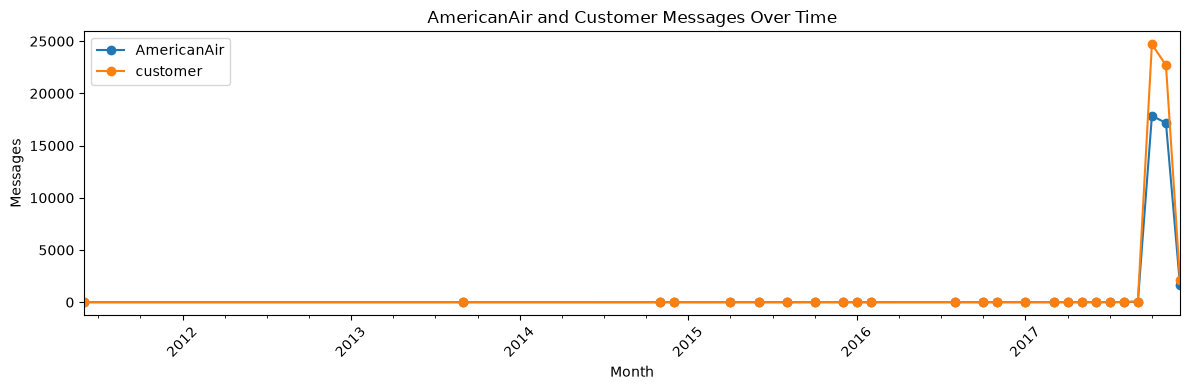

In [6]:
df["year_month"] = df["created_at"].dt.tz_localize(None).dt.to_period("M")
monthly = df.groupby(["year_month", "inbound"]).size().unstack(fill_value=0)
monthly.columns = ["AmericanAir" if column is False else "customer" for column in monthly.columns]
monthly.plot(figsize=(12, 4), marker="o")
plt.title("AmericanAir and Customer Messages Over Time")
plt.xlabel("Month")
plt.ylabel("Messages")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Message direction

In [7]:
parent_map = (
    df.set_index("tweet_id")["in_response_to_tweet_id"]
    .dropna()
    .to_dict()
)


def find_root(tweet_id):
    current = tweet_id
    visited = set()
    while current in parent_map and current not in visited:
        visited.add(current)
        parent = parent_map[current]
        if pd.isna(parent):
            break
        current = parent
    return current


df["conversation_id"] = df["tweet_id"].map(find_root)
print("Conversations:", df["conversation_id"].nunique())

Conversations: 26387


# Message volume over time

In [8]:
conversation_stats = (
    df.groupby("conversation_id")
    .agg(
        message_count=("tweet_id", "count"),
        customer_messages=("inbound", "sum"),
        unique_authors=("author_id", "nunique"),
        first_message=("created_at", "min"),
        last_message=("created_at", "max"),
    )
)
conversation_stats["americanair_messages"] = (
    conversation_stats["message_count"] - conversation_stats["customer_messages"]
)
conversation_stats["duration_hours"] = (
    conversation_stats["last_message"] - conversation_stats["first_message"]
).dt.total_seconds().div(3600)
conversation_stats["has_agent_response"] = (
    conversation_stats["americanair_messages"] > 0
)
conversation_stats.describe(include="all")

,message_count,customer_messages,unique_authors,first_message,last_message,americanair_messages,duration_hours,has_agent_response
count,26387.000000,26387.000000,26387.000000,26387,26387,26387.000000,26387.000000,26387
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26387
mean,3.275439,1.882177,2.092773,2017-11-01 14:29:37.817599+00:00,2017-11-02 12:03:19.543562+00:00,1.393262,21.561591,NaN
min,2.000000,1.000000,2.000000,2011-06-16 13:38:36+00:00,2017-10-04 02:55:21+00:00,1.000000,0.000556,NaN
25%,2.000000,1.000000,2.000000,2017-10-17 15:54:35.500000+00:00,2017-10-17 21:03:02.500000+00:00,1.000000,0.142222,NaN
50%,2.000000,1.000000,2.000000,2017-11-01 16:59:38+00:00,2017-11-01 21:49:34+00:00,1.000000,0.364167,NaN
75%,4.000000,2.000000,2.000000,2017-11-16 22:20:58.500000+00:00,2017-11-17 01:00:20.500000+00:00,2.000000,0.957222,NaN
max,204.000000,201.000000,171.000000,2017-12-03 22:55:11+00:00,2017-12-03 22:57:54+00:00,40.000000,56425.424722,NaN


# Direct customer-to-AmericanAir replies

In [9]:
customer_lookup = df.loc[
    df["inbound"] == True,
    ["tweet_id", "author_id", "text"],
].rename(
    columns={
        "tweet_id": "customer_tweet_id",
        "author_id": "customer_author_id",
        "text": "customer_message",
    }
)

american_replies = df.loc[
    (df["author_id"] == BRAND_HANDLE)
    & (df["inbound"] == False)
    & df["in_response_to_tweet_id"].notna()
].copy()

reply_pairs_df = american_replies.merge(
    customer_lookup,
    left_on="in_response_to_tweet_id",
    right_on="customer_tweet_id",
    how="inner",
)
reply_pairs_df = reply_pairs_df.rename(
    columns={"tweet_id": "agent_tweet_id", "text": "agent_response"}
)
reply_pairs_df = reply_pairs_df[
    [
        "customer_tweet_id",
        "agent_tweet_id",
        "customer_author_id",
        "customer_message",
        "agent_response",
        "conversation_id",
        "created_at",
    ]
]
print("Direct customer -> AmericanAir reply pairs:", len(reply_pairs_df))
reply_pairs_df.head(10)

Direct customer -> AmericanAir reply pairs: 36531


,customer_tweet_id,agent_tweet_id,customer_author_id,customer_message,agent_response,conversation_id,created_at
0,626918,626916,268460,@americanair Do you have a number to call you and check the flight status?,"@28752 Text ""FLYAA"" (35922) with your flight number to get instant flight info!",626918,2011-06-16 13:49:04+00:00
1,2502768,2502766,713819,"Personally @97121 I think @AmericanAir needs a dance floor, a disco ball, a cocktail bar with vintage cocktail waitresses, and... hmm","@713819 That sounds like fun, Sunita! We can all wear disco fashion.",2502768,2013-09-04 18:33:04+00:00
2,1312223,1312222,426644,@AmericanAir cld you pls update passengers of AA5 from DFW as to status of 2nd plane on this service after mech failure? Are we flying out?,@426644 We know you're anxious to be on your way. We'll have an update on AA5 at 7p. Thanks for your patience.,1312223,2014-12-09 00:24:07+00:00
3,863025,863022,324933,"Wow. I fly a lot. But @AmericanAir is above the rest. They care about people. I fly 100,000 miles a year and they are the BEST.","@324933 Thanks for the shout-out, Charlie! Now let's make more of those 100,000 with us. #wink",863025,2015-04-06 00:16:53+00:00
4,2863333,2863332,442183,@AmericanAir YOU FOUND HIM!!!!,"@442183 Yes, we did! Snape was on board for his moment in the social spotlight. #AATeam",2863334,2015-06-05 18:50:14+00:00
5,2863331,2863329,442183,@AmericanAir I am so so happy finally there is a name to that face that has set the internet alight! :D,@442183 We love your enthusiasm! We're happy to share #SnAApe with the rest of the world.,2863334,2015-06-05 18:59:48+00:00
6,1347536,1347534,434250,I recommend people not use @AmericanAir unless they want poor service and/or want to be stuck somewhere all night. http://t.co/QCe2W0y50l,@434250 We're truly sorry your travel isn't going as intended. We hope you'll reconsider and give us another chance.,1347536,2015-08-07 11:50:15+00:00
7,1183395,1183394,398285,@AmericanAir I have AAdvantage Visa &amp; Master cards &amp; they WILL NOT WORK IN SAMAUNG PAY OR ANDROID PAY but work in Apple Pay &amp; Google pay WTF,"@398285 We're a bit confused by your tweet, Alex. Are you trying to complete a payment on our Website?",1183395,2015-10-05 20:49:04+00:00
8,1183393,1183392,398285,@AmericanAir I’m trying to add my AAdvantage cards to Samsung Pay but it looks like your partner Citi won’t allow it http://t.co/ysdNHVXYN2,"@398285 AAdvantage cards are not eligible to be used for mobile payments, Alex.",1183395,2015-10-06 06:18:26+00:00
9,1183390,1183385,398285,@AmericanAir Then why is it I'm able to add it to Apple Pay on my iPhone 6s Plus. Plus this offer I got in May? http://t.co/wWQ4Eex82I,"@398285 Our apologies, Alex. They're not eligible for Samsung or Android Pay.",1183395,2015-10-06 06:31:27+00:00


In [10]:
reply_pairs_df["customer_length"] = reply_pairs_df["customer_message"].fillna("").str.len()
reply_pairs_df["agent_length"] = reply_pairs_df["agent_response"].fillna("").str.len()

reply_metrics = reply_pairs_df[["customer_length", "agent_length"]].describe()
reply_metrics

,customer_length,agent_length
count,36531.000000,36531.000000
mean,123.411130,103.372916
std,52.702009,29.473671
min,12.000000,13.000000
25%,89.000000,83.000000
50%,125.000000,107.000000
75%,144.000000,128.000000
max,332.000000,152.000000


# Reusable support insights

In [11]:
insights = pd.Series(
    {
        "total_messages": len(df),
        "customer_messages": int((df["inbound"] == True).sum()),
        "americanair_messages": int(
            ((df["inbound"] == False) & (df["author_id"] == BRAND_HANDLE)).sum()
        ),
        "conversations": int(df["conversation_id"].nunique()),
        "support_conversations": int(
            (
                (conversation_stats["customer_messages"] > 0)
                & (conversation_stats["americanair_messages"] > 0)
            ).sum()
        ),
        "direct_reply_pairs": len(reply_pairs_df),
        "unanswered_customer_conversations": int(
            (
                (conversation_stats["customer_messages"] > 0)
                & ~conversation_stats["has_agent_response"]
            ).sum()
        ),
    }
)
insights

total_messages                       86429
customer_messages                    49665
americanair_messages                 36764
conversations                        26387
support_conversations                26387
direct_reply_pairs                   36531
unanswered_customer_conversations        0
dtype: int64